## importing necessary packages

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
print(df["TotalCharges"])
print("TotalCharges dtype:", df["TotalCharges"].dtype)
print("Rows with whitespace in TotalCharges:", (df["TotalCharges"].str.strip() == "").sum())

0         29.85
1        1889.5
2        108.15
3       1840.75
4        151.65
         ...   
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: TotalCharges, Length: 7043, dtype: str
TotalCharges dtype: str
Rows with whitespace in TotalCharges: 11


In [6]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df['TotalCharges'] = df["TotalCharges"].fillna(0)

In [7]:
print("Before conversion: " + str(df['Churn'].dtype))
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print("After conversion: " + str(df['Churn'].dtype))

Before conversion: str
After conversion: int64


In [8]:
print(f"\nRemaining nulls:\n{df.isnull().sum()[df.isnull().sum() > 0]}")


Remaining nulls:
Series([], dtype: int64)


In [9]:
churrn_counts = df['Churn'].value_counts()
print(churrn_counts)

Churn
0    5174
1    1869
Name: count, dtype: int64


C:\Users\chaud\AppData\Local\Temp\ipykernel_11696\3994627088.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn',


Text(0.5, 1.0, 'Customer Churn Distribution')

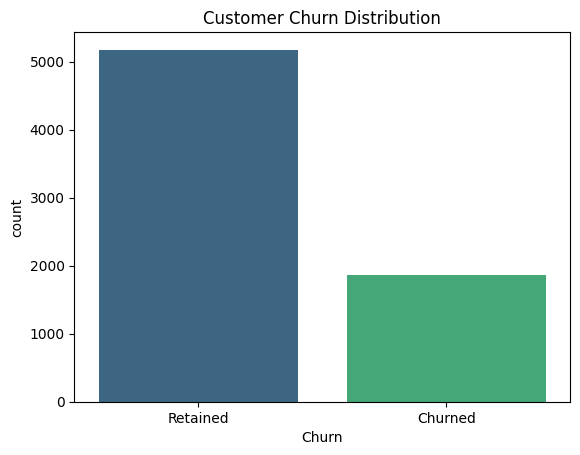

In [10]:
churn_plot = df[['Churn']].copy()
churn_plot['Churn'] = df['Churn'].map({0: 'Retained', 1: 'Churned'})
sns.countplot(x='Churn', 
              data = churn_plot, 
              palette='viridis')
plt.title('Customer Churn Distribution')    

In [11]:
df[['tenure']].value_counts()

tenure
1         613
72        362
2         238
3         200
4         176
         ... 
28         57
39         56
44         51
36         50
0          11
Name: count, Length: 73, dtype: int64

In [12]:
df["tenure_bucket"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0–12 months", "13–24 months", "25–48 months", "49–72 months"],
    include_lowest=True
)

C:\Users\chaud\AppData\Local\Temp\ipykernel_11696\3743999630.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="tenure_bucket", y="Churn", data=tenure_churn_plot, palette='viridis')


Text(0.5, 0, 'Tenure Bucket')

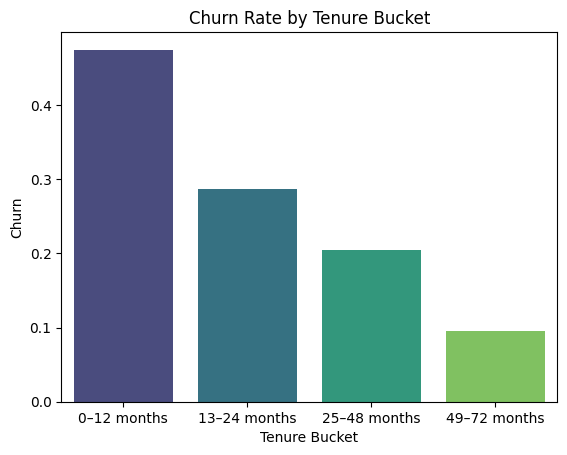

In [13]:
tenure_churn_plot = df.groupby("tenure_bucket")["Churn"].mean().reset_index()
sns.barplot(x="tenure_bucket", y="Churn", data=tenure_churn_plot, palette='viridis')
plt.title("Churn Rate by Tenure Bucket")
plt.xlabel("Tenure Bucket") 

C:\Users\chaud\AppData\Local\Temp\ipykernel_11696\3910869560.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=internet_churn_plot.index,


Text(0, 0.5, 'Churn Rate')

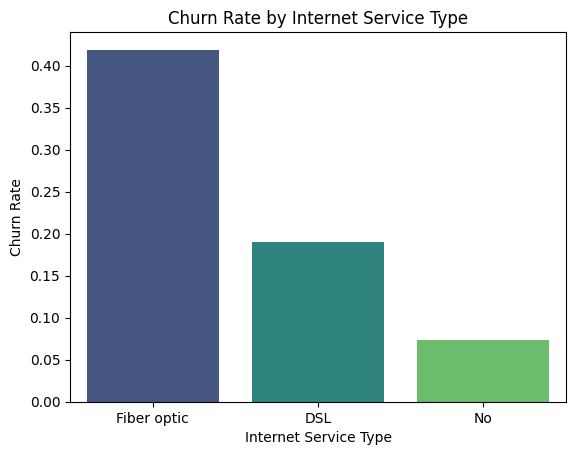

In [17]:
internet_churn_plot = df.groupby('InternetService')['Churn'].mean().sort_values(ascending = False)
sns.barplot(x=internet_churn_plot.index, 
            y=internet_churn_plot.values, 
            palette='viridis')
plt.title("Churn Rate by Internet Service Type")
plt.xlabel("Internet Service Type")
plt.ylabel("Churn Rate")

C:\Users\chaud\AppData\Local\Temp\ipykernel_11696\2625076752.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_churn_plot.index,


Text(0, 0.5, 'Churn Rate')

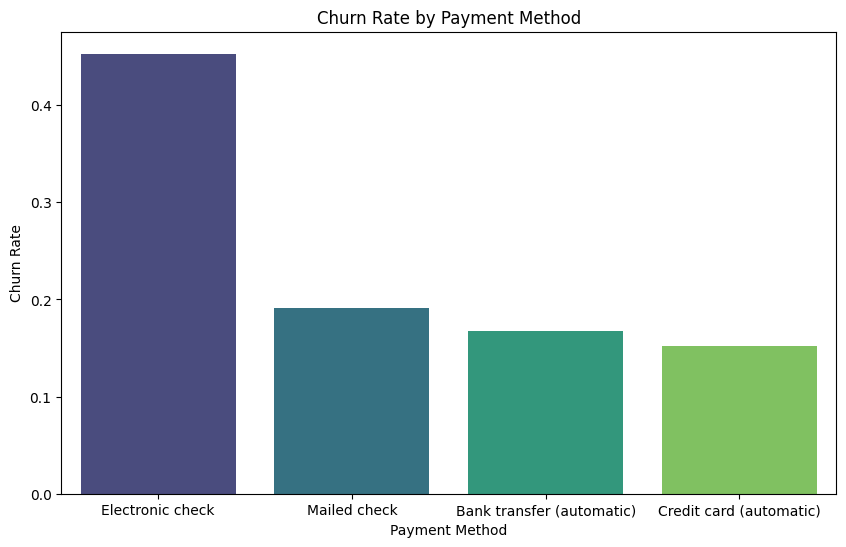

In [37]:
payment_churn_plot = df.groupby("PaymentMethod")["Churn"].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=payment_churn_plot.index, 
            y=payment_churn_plot.values, 
            palette='viridis')
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate")
